<a href="https://colab.research.google.com/github/Vanitha-Jain/capstone/blob/Feature-selection/AtomPair2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import os

filename = '/content/AtomPairs2D.csv'  # Corrected filename

if os.path.exists(filename):
    data = pd.read_csv(filename)
    print("File loaded successfully!")  # Optional confirmation message
    print(data)
else:
    print(f"Error: File '{filename}' not found.")

File loaded successfully!
               Name  AD2D1  AD2D2  AD2D3  AD2D4  AD2D5  AD2D6  AD2D7  AD2D8  \
0      CHEMBL167155      1      1      1      1      0      0      0      0   
1      CHEMBL166740      1      1      1      1      0      0      0      0   
2      CHEMBL165038      1      1      1      1      0      0      1      0   
3      CHEMBL435857      1      1      1      1      0      0      1      0   
4      CHEMBL352783      1      1      1      1      0      0      0      0   
...             ...    ...    ...    ...    ...    ...    ...    ...    ...   
1224  CHEMBL5429863      1      1      0      0      0      0      0      0   
1225  CHEMBL5436920      1      1      0      0      0      0      0      0   
1226  CHEMBL5405698      1      1      0      0      0      0      0      0   
1227  CHEMBL5416562      1      1      0      0      0      0      0      0   
1228      CHEMBL165      1      0      1      0      0      0      0      0   

      AD2D9  ...  AD2D772

In [6]:
data.dtypes

,0
Name,object
AD2D1,int64
AD2D2,int64
AD2D3,int64
AD2D4,int64
...,...
AD2D777,int64
AD2D778,int64
AD2D779,int64
AD2D780,int64


In [13]:
data['bioactivity_class'].replace('active', 'P', inplace=True)
data['bioactivity_class'].replace('inactive', 'N', inplace=True)
data.rename(columns = {"bioactivity_class": "class"}, inplace = True)
data

<ipython-input-13-d75cbf56e791>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bioactivity_class'].replace('active', 'P', inplace=True)
<ipython-input-13-d75cbf56e791>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

,Name,AD2D1,AD2D2,AD2D3,AD2D4,AD2D5,AD2D6,AD2D7,AD2D8,AD2D9,...,AD2D772,AD2D773,AD2D774,AD2D775,AD2D776,AD2D777,AD2D778,AD2D779,AD2D780,class
0,CHEMBL167155,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1,CHEMBL166740,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
2,CHEMBL165038,1,1,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,N
3,CHEMBL435857,1,1,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,N
4,CHEMBL352783,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1225,CHEMBL5436920,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1226,CHEMBL5405698,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1227,CHEMBL5416562,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N


In [14]:
data.isnull().sum().sum()

0

In [15]:
data.dropna(inplace =True)
data.isnull().sum().sum()

0

In [16]:
data1 = data.iloc[:,1:781]
data1
data2 = data.iloc[:,-1]

In [17]:
data1
data2

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [18]:
from sklearn.feature_selection import VarianceThreshold
threshold = VarianceThreshold(threshold=.1)
def variance_threshold_selector(data1, threshold=0.10):
    selector = VarianceThreshold(threshold)
    selector.fit(data1)
    return data[data1.columns[selector.get_support(indices=True)]]
data1_HV = variance_threshold_selector(data1)


In [19]:
data1_HV = variance_threshold_selector(data1)
data1_HV

,AD2D2,AD2D4,AD2D6,AD2D7,AD2D12,AD2D13,AD2D15,AD2D25,AD2D80,AD2D82,...,AD2D648,AD2D704,AD2D705,AD2D706,AD2D708,AD2D709,AD2D714,AD2D715,AD2D716,AD2D726
0,1,1,0,0,0,0,1,1,1,1,...,0,0,1,1,0,0,0,0,0,1
1,1,1,0,0,0,0,1,1,1,1,...,0,0,1,1,0,0,0,0,0,1
2,1,1,0,1,1,0,1,1,1,1,...,0,0,0,0,0,1,1,0,0,0
3,1,1,0,1,1,0,1,1,1,1,...,0,0,0,0,0,1,1,0,0,0
4,1,1,0,0,0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1225,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1226,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1227,1,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0


In [20]:
data2_HV = pd.merge(data1_HV,data2,left_index=True,right_index=True)
data2_HV

,AD2D2,AD2D4,AD2D6,AD2D7,AD2D12,AD2D13,AD2D15,AD2D25,AD2D80,AD2D82,...,AD2D704,AD2D705,AD2D706,AD2D708,AD2D709,AD2D714,AD2D715,AD2D716,AD2D726,class
0,1,1,0,0,0,0,1,1,1,1,...,0,1,1,0,0,0,0,0,1,N
1,1,1,0,0,0,0,1,1,1,1,...,0,1,1,0,0,0,0,0,1,N
2,1,1,0,1,1,0,1,1,1,1,...,0,0,0,0,1,1,0,0,0,N
3,1,1,0,1,1,0,1,1,1,1,...,0,0,0,0,1,1,0,0,0,N
4,1,1,0,0,0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,N
1225,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,N
1226,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,N
1227,1,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,N


In [22]:
## remove features that display high correlation with many othe features
correlated_features_1 = set()
corr_matrix_class = data2_HV.corr(numeric_only=True)


for i in range(len(corr_matrix_class.columns)):
    for j in range(i):
        if abs(corr_matrix_class.iloc[i, j]) > 0.9:
            colname = corr_matrix_class.columns[i]
            correlated_features_1.add(colname)
correlated_features_1


{'AD2D158',
 'AD2D160',
 'AD2D162',
 'AD2D163',
 'AD2D168',
 'AD2D236',
 'AD2D238',
 'AD2D240',
 'AD2D241',
 'AD2D246',
 'AD2D314',
 'AD2D316',
 'AD2D318',
 'AD2D392',
 'AD2D394',
 'AD2D396',
 'AD2D397',
 'AD2D402',
 'AD2D470',
 'AD2D472',
 'AD2D475',
 'AD2D480',
 'AD2D552',
 'AD2D553',
 'AD2D558',
 'AD2D628',
 'AD2D630',
 'AD2D709',
 'AD2D80',
 'AD2D82',
 'AD2D84',
 'AD2D85',
 'AD2D90'}

In [23]:
def remove_correlated_features(features, data):
    for x in features:
        data.drop(x, axis=1, inplace=True)
    return data

In [24]:
data3= remove_correlated_features(correlated_features_1, data2_HV)
data3

,AD2D2,AD2D4,AD2D6,AD2D7,AD2D12,AD2D13,AD2D15,AD2D25,AD2D91,AD2D92,...,AD2D648,AD2D704,AD2D705,AD2D706,AD2D708,AD2D714,AD2D715,AD2D716,AD2D726,class
0,1,1,0,0,0,0,1,1,0,1,...,0,0,1,1,0,0,0,0,1,N
1,1,1,0,0,0,0,1,1,0,1,...,0,0,1,1,0,0,0,0,1,N
2,1,1,0,1,1,0,1,1,0,1,...,0,0,0,0,0,1,0,0,0,N
3,1,1,0,1,1,0,1,1,0,1,...,0,0,0,0,0,1,0,0,0,N
4,1,1,0,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1225,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1226,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1227,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,N


In [25]:
data3.to_csv('AP2.csv')

In [29]:
X = data3.iloc[:,1:54]  #independent columns
X
y = data3.iloc[:,-1]
y   #target column i.e price range


,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [30]:
X

,AD2D4,AD2D6,AD2D7,AD2D12,AD2D13,AD2D15,AD2D25,AD2D91,AD2D92,AD2D102,...,AD2D638,AD2D648,AD2D704,AD2D705,AD2D706,AD2D708,AD2D714,AD2D715,AD2D716,AD2D726
0,1,0,0,0,0,1,1,0,1,1,...,1,0,0,1,1,0,0,0,0,1
1,1,0,0,0,0,1,1,0,1,1,...,1,0,0,1,1,0,0,0,0,1
2,1,0,1,1,0,1,1,0,1,1,...,0,0,0,0,0,0,1,0,0,0
3,1,0,1,1,0,1,1,0,1,1,...,0,0,0,0,0,0,1,0,0,0
4,1,0,0,0,0,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1225,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1227,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [31]:
from sklearn.preprocessing import StandardScaler
# y = data['class']
# X_features =data.drop(columns='class')
scaler = StandardScaler()
X_transform = scaler.fit_transform(X)
X_transform_pd = pd.DataFrame(X_transform, columns = X.columns)
X_transform_pd

# #Standardize/normalize the data
# from sklearn.preprocessing import MinMaxScaler
# sc = MinMaxScaler()
# X_transform = sc.fit_transform(X)
# X_transform

,AD2D4,AD2D6,AD2D7,AD2D12,AD2D13,AD2D15,AD2D25,AD2D91,AD2D92,AD2D102,...,AD2D638,AD2D648,AD2D704,AD2D705,AD2D706,AD2D708,AD2D714,AD2D715,AD2D716,AD2D726
0,1.736761,-0.484949,-0.403391,-0.719225,-0.500254,2.575566,2.671904,-0.866437,0.818436,1.240668,...,1.157995,-0.610888,-1.262073,0.49771,2.360549,-0.415584,-0.627235,-0.418273,-0.706244,1.520746
1,1.736761,-0.484949,-0.403391,-0.719225,-0.500254,2.575566,2.671904,-0.866437,0.818436,1.240668,...,1.157995,-0.610888,-1.262073,0.49771,2.360549,-0.415584,-0.627235,-0.418273,-0.706244,1.520746
2,1.736761,-0.484949,2.478981,1.390386,-0.500254,2.575566,2.671904,-0.866437,0.818436,1.240668,...,-0.863562,-0.610888,-1.262073,-2.00920,-0.423630,-0.415584,1.594298,-0.418273,-0.706244,-0.657572
3,1.736761,-0.484949,2.478981,1.390386,-0.500254,2.575566,2.671904,-0.866437,0.818436,1.240668,...,-0.863562,-0.610888,-1.262073,-2.00920,-0.423630,-0.415584,1.594298,-0.418273,-0.706244,-0.657572
4,1.736761,-0.484949,-0.403391,-0.719225,-0.500254,2.575566,2.671904,-0.866437,0.818436,1.240668,...,-0.863562,-0.610888,-1.262073,-2.00920,-0.423630,-0.415584,-0.627235,-0.418273,-0.706244,-0.657572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,-0.575784,-0.484949,-0.403391,-0.719225,-0.500254,-0.388264,-0.374265,-0.866437,-1.221843,-0.806018,...,-0.863562,-0.610888,-1.262073,-2.00920,-0.423630,-0.415584,-0.627235,-0.418273,-0.706244,-0.657572
1225,-0.575784,-0.484949,-0.403391,-0.719225,-0.500254,-0.388264,-0.374265,-0.866437,-1.221843,-0.806018,...,-0.863562,-0.610888,-1.262073,-2.00920,-0.423630,-0.415584,-0.627235,-0.418273,-0.706244,-0.657572
1226,-0.575784,-0.484949,-0.403391,-0.719225,-0.500254,-0.388264,-0.374265,-0.866437,-1.221843,-0.806018,...,-0.863562,-0.610888,-1.262073,-2.00920,-0.423630,-0.415584,-0.627235,-0.418273,-0.706244,-0.657572
1227,-0.575784,-0.484949,-0.403391,-0.719225,-0.500254,-0.388264,-0.374265,-0.866437,-1.221843,-0.806018,...,-0.863562,-0.610888,0.792348,-2.00920,-0.423630,-0.415584,-0.627235,-0.418273,-0.706244,-0.657572


In [32]:
## Split data into train and test sets.
from sklearn.model_selection import train_test_split
seed_num = 10
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=seed_num)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(860, 53)
(860,)
(369, 53)
(369,)


In [33]:
X_train

,AD2D4,AD2D6,AD2D7,AD2D12,AD2D13,AD2D15,AD2D25,AD2D91,AD2D92,AD2D102,...,AD2D638,AD2D648,AD2D704,AD2D705,AD2D706,AD2D708,AD2D714,AD2D715,AD2D716,AD2D726
387,1,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,0
250,1,1,0,1,0,1,1,0,1,1,...,1,0,1,1,1,1,1,1,1,0
378,0,0,1,1,0,0,0,1,1,0,...,1,0,1,1,0,0,1,0,0,0
73,0,0,0,0,0,0,0,0,1,1,...,0,1,1,1,0,0,0,0,0,0
1185,0,0,1,1,0,0,0,1,1,0,...,0,0,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
1180,0,0,1,1,0,0,0,1,1,0,...,0,0,1,1,0,0,1,0,1,1
1147,1,1,0,1,0,0,0,0,0,1,...,0,0,1,1,1,1,1,0,0,0
527,1,0,0,0,1,1,1,1,1,1,...,1,0,1,1,1,0,0,0,0,0


In [34]:
y_train

,class
387,N
250,N
378,N
73,N
1185,P
...,...
733,N
1180,P
1147,N
527,P


In [35]:
Training_set  = pd.concat([X_train,y_train],axis=1)
Training_set


,AD2D4,AD2D6,AD2D7,AD2D12,AD2D13,AD2D15,AD2D25,AD2D91,AD2D92,AD2D102,...,AD2D648,AD2D704,AD2D705,AD2D706,AD2D708,AD2D714,AD2D715,AD2D716,AD2D726,class
387,1,0,0,0,0,0,0,0,0,0,...,0,1,1,1,0,0,0,0,0,N
250,1,1,0,1,0,1,1,0,1,1,...,0,1,1,1,1,1,1,1,0,N
378,0,0,1,1,0,0,0,1,1,0,...,0,1,1,0,0,1,0,0,0,N
73,0,0,0,0,0,0,0,0,1,1,...,1,1,1,0,0,0,0,0,0,N
1185,0,0,1,1,0,0,0,1,1,0,...,0,1,1,0,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,0,0,0,0,0,0,1,...,0,1,1,0,0,0,0,0,0,N
1180,0,0,1,1,0,0,0,1,1,0,...,0,1,1,0,0,1,0,1,1,P
1147,1,1,0,1,0,0,0,0,0,1,...,0,1,1,1,1,1,0,0,0,N
527,1,0,0,0,1,1,1,1,1,1,...,0,1,1,1,0,0,0,0,0,P


In [41]:
Training_set.to_csv('AtomPair2D_Training_set.csv')

In [42]:
Testing_set  = pd.concat([X_test,y_test],axis=1)
Testing_set

,AD2D4,AD2D6,AD2D7,AD2D12,AD2D13,AD2D15,AD2D25,AD2D91,AD2D92,AD2D102,...,AD2D648,AD2D704,AD2D705,AD2D706,AD2D708,AD2D714,AD2D715,AD2D716,AD2D726,class
693,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,N
834,0,0,0,1,1,0,0,1,0,0,...,0,0,1,0,0,1,0,0,0,N
1016,0,0,0,0,0,0,0,1,1,0,...,0,1,1,0,0,0,0,1,0,P
1113,0,0,0,0,0,0,0,0,0,1,...,1,0,1,0,0,0,0,0,0,P
31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,1,1,0,1,0,1,1,1,1,1,...,0,1,1,0,1,1,1,0,0,P
909,0,0,0,0,0,0,0,1,1,0,...,0,1,1,0,0,0,1,1,1,P
270,1,1,0,1,0,1,1,0,1,1,...,0,1,1,1,1,1,0,0,0,N
349,1,0,0,0,0,0,0,0,1,1,...,1,1,1,1,0,0,0,1,0,P


In [43]:
Testing_set.to_csv('Atompair2D_Testing_set.csv')

In [44]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
kBest = SelectKBest(mutual_info_classif, k = 15)
X_kBestFeatures = kBest.fit_transform(X_train, y_train)
X_kBestFeatures.shape


(860, 15)

In [45]:
kBest.get_support(True)

array([13, 15, 16, 19, 21, 24, 27, 29, 36, 37, 38, 39, 45, 50, 51])

In [46]:
X_kBestFeatures = Training_set.iloc[:, kBest.get_support(True)]
X_kBestFeatures.columns


Index(['AD2D180', 'AD2D248', 'AD2D258', 'AD2D326', 'AD2D336', 'AD2D404',
       'AD2D474', 'AD2D482', 'AD2D560', 'AD2D569', 'AD2D570', 'AD2D626',
       'AD2D704', 'AD2D715', 'AD2D716'],
      dtype='object')

In [47]:
f = kBest.get_support(1)
X_new = X_train[X_train.columns[f]]
X_new
data_scores = pd.DataFrame(kBest.scores_)
data_columns = pd.DataFrame(X.columns)

In [48]:
#Concat two dataframes for better visualization
featureScores = pd.concat([data_columns, data_scores], axis = 1)

#naming the dataframe columns
featureScores.columns = ['Features', 'Scores']
featureScores


,Features,Scores
0,AD2D4,0.008452
1,AD2D6,0.010022
2,AD2D7,0.000000
3,AD2D12,0.000000
4,AD2D13,0.010022
5,AD2D15,0.000000
6,AD2D25,0.015127
7,AD2D91,0.011731
8,AD2D92,0.000000
9,AD2D102,0.000429


In [49]:
#Print top 25 best features
print(featureScores.nlargest(15, 'Scores'))

   Features    Scores
24  AD2D404  0.057433
13  AD2D180  0.055448
38  AD2D570  0.041864
37  AD2D569  0.040173
50  AD2D715  0.039440
45  AD2D704  0.035860
51  AD2D716  0.035206
36  AD2D560  0.034495
16  AD2D258  0.029520
15  AD2D248  0.027918
19  AD2D326  0.026094
29  AD2D482  0.025866
21  AD2D336  0.024675
27  AD2D474  0.024577
39  AD2D626  0.024295


In [50]:
Graph = (featureScores.nlargest(15, 'Scores'))
Graph

,Features,Scores
24,AD2D404,0.057433
13,AD2D180,0.055448
38,AD2D570,0.041864
37,AD2D569,0.040173
50,AD2D715,0.039440
45,AD2D704,0.035860
51,AD2D716,0.035206
36,AD2D560,0.034495
16,AD2D258,0.029520
15,AD2D248,0.027918


In [51]:
Graph.to_csv('AtomPair2D.csv')

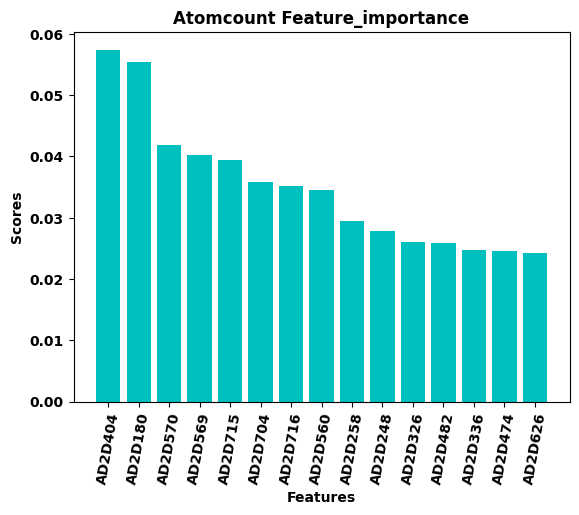

<Figure size 1000x1000 with 0 Axes>

In [69]:
import matplotlib.pyplot as plt
data = pd.read_csv('AtomPair2D.csv')
df = pd.DataFrame(data)
X = list(df.iloc[:, 1])
Y = list(df.iloc[:, 2])
plt.bar(X, Y, color='c')
plt.title("Atomcount Feature_importance", fontweight="bold")
plt.xlabel("Features", fontweight = 'bold')
plt.ylabel("Scores", fontweight = 'bold')
plt.xticks(rotation = 80, fontweight="bold")
plt.yticks(fontweight="bold")
fig = plt.figure(figsize=(10, 10))
plt.savefig("Features.jpg", bbox_inches = 'tight')

In [55]:
Trainset = pd.concat([X_new,y_train],axis=1)
Trainset

,AD2D180,AD2D248,AD2D258,AD2D326,AD2D336,AD2D404,AD2D474,AD2D482,AD2D560,AD2D569,AD2D570,AD2D626,AD2D704,AD2D715,AD2D716,class
387,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,N
250,0,1,0,0,0,0,1,1,0,1,0,1,1,1,1,N
378,1,1,1,1,1,1,0,1,1,0,0,1,1,0,0,N
73,0,1,0,1,1,1,0,0,1,0,0,1,1,0,0,N
1185,0,1,1,1,0,1,0,1,0,1,0,1,1,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0,N
1180,0,1,0,1,0,1,0,1,1,1,1,1,1,0,1,P
1147,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,N
527,0,1,0,1,0,1,0,1,1,0,0,1,1,0,0,P


In [56]:
f = kBest.get_support(1)
Test_new = X_test[X_test.columns[f]]
Test_new

,AD2D180,AD2D248,AD2D258,AD2D326,AD2D336,AD2D404,AD2D474,AD2D482,AD2D560,AD2D569,AD2D570,AD2D626,AD2D704,AD2D715,AD2D716
693,1,1,1,1,1,1,0,1,1,0,1,0,0,0,0
834,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0
1016,0,1,1,1,1,0,0,1,1,0,0,1,1,0,1
1113,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0
31,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0,1,0,0,0,1,1,0,0,0,0,1,1,1,0
909,0,1,0,1,0,1,0,1,1,0,0,1,1,1,1
270,0,1,0,0,0,0,1,1,0,0,0,1,1,0,0
349,0,1,0,1,1,1,0,1,1,0,1,1,1,0,1


In [57]:
Testset = pd.concat([Test_new,y_test],axis=1)
Testset

,AD2D180,AD2D248,AD2D258,AD2D326,AD2D336,AD2D404,AD2D474,AD2D482,AD2D560,AD2D569,AD2D570,AD2D626,AD2D704,AD2D715,AD2D716,class
693,1,1,1,1,1,1,0,1,1,0,1,0,0,0,0,N
834,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,N
1016,0,1,1,1,1,0,0,1,1,0,0,1,1,0,1,P
1113,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,P
31,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0,1,0,0,0,1,1,0,0,0,0,1,1,1,0,P
909,0,1,0,1,0,1,0,1,1,0,0,1,1,1,1,P
270,0,1,0,0,0,0,1,1,0,0,0,1,1,0,0,N
349,0,1,0,1,1,1,0,1,1,0,1,1,1,0,1,P


In [58]:
Trainset.to_csv('Trainset_AtomPair2D_after_feature.csv')
Testset.to_csv('Testset_Atompair2D_after_feature.csv')


In [60]:
Trainset['class'].replace('N', 0, inplace=True)
Trainset['class'].replace('P', 1, inplace=True)
Trainset.rename(columns = {"class": "class"}, inplace = True)
Trainset

<ipython-input-60-e976ed617192>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Trainset['class'].replace('N', 0, inplace=True)
<ipython-input-60-e976ed617192>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,AD2D180,AD2D248,AD2D258,AD2D326,AD2D336,AD2D404,AD2D474,AD2D482,AD2D560,AD2D569,AD2D570,AD2D626,AD2D704,AD2D715,AD2D716,class
387,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
250,0,1,0,0,0,0,1,1,0,1,0,1,1,1,1,0
378,1,1,1,1,1,1,0,1,1,0,0,1,1,0,0,0
73,0,1,0,1,1,1,0,0,1,0,0,1,1,0,0,0
1185,0,1,1,1,0,1,0,1,0,1,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0,0
1180,0,1,0,1,0,1,0,1,1,1,1,1,1,0,1,1
1147,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0
527,0,1,0,1,0,1,0,1,1,0,0,1,1,0,0,1


In [61]:
Testset['class'].replace('N', 0, inplace=True)
Testset['class'].replace('P', 1, inplace=True)
Testset.rename(columns = {"class": "class"}, inplace = True)
Testset.head()

<ipython-input-61-c538cf0d9b31>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Testset['class'].replace('N', 0, inplace=True)
<ipython-input-61-c538cf0d9b31>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,AD2D180,AD2D248,AD2D258,AD2D326,AD2D336,AD2D404,AD2D474,AD2D482,AD2D560,AD2D569,AD2D570,AD2D626,AD2D704,AD2D715,AD2D716,class
693,1,1,1,1,1,1,0,1,1,0,1,0,0,0,0,0
834,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0
1016,0,1,1,1,1,0,0,1,1,0,0,1,1,0,1,1
1113,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1
31,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1


In [62]:
Trainset.to_csv('Trainset1_AtomPair2D_after_feature.csv')
Testset.to_csv('Testset1_AtomPair2D_after_feature.csv')